<a href="https://colab.research.google.com/github/aaronowens15/cs_course_project/blob/main/Homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Graph Definitions

In [4]:
# BFS Graph
BFSGraph = {
    "A": ["B", "D", "L"],
    "B": ["A", "C", "L"],
    "C": ["B", "E", "F", "D"],
    "D": ["A", "C", "I"],
    "E": ["L", "C", "F", "M"],
    "F": ["C", "E", "G", "M"],
    "G": ["F", "K", "N"],
    "H": ["I", "J", "G"],
    "I": ["D", "H"],
    "J": ["H", "K"],
    "K": ["G", "J"],
    "L": ["A", "B", "E", "M"],
    "M": ["L", "E", "F", "N"],
    "N": ["M", "G"],
}


# Dijkstra Graph
DijkstraGraph = {
    "A": [("B", 15), ("D", 12), ("L", 10)],
    "B": [("A", 15), ("C",  1), ("L",  8)],
    "C": [("B",  1), ("D", 10), ("E", 17), ("F", 25)],
    "D": [("A", 12), ("C", 10), ("I", 22)],
    "E": [("C", 17), ("F", 30), ("L", 18), ("M", 18)],
    "F": [("C", 25), ("E", 30), ("G", 13), ("M", 35)],
    "G": [("F", 13), ("H", 40), ("K", 15), ("N",  5)],
    "H": [("G", 40), ("I", 12), ("J", 23)],
    "I": [("D", 22), ("H", 12)],
    "J": [("H", 23), ("K", 14)],
    "K": [("G", 15), ("J", 14)],
    "L": [("A", 10), ("B",  8), ("E", 18), ("M", 18)],
    "M": [("E", 18), ("F", 35), ("L", 18), ("N",  9)],
    "N": [("G",  5), ("M",  9)],
}

## BFS Algorithm for Unweighted Graph

In [5]:
from collections import deque

def bfs_shortest_path(graph, start, end):
    queue = deque([(start, [start])])  # Queue stores (current_node, path_to_current_node)
    visited = {start}

    print(f"Starting BFS from {start} to {end}")

    while queue:
        current_node, path = queue.popleft()

        if current_node == end:
            return path

        newly_discovered_nodes = []
        for neighbor in graph[current_node]:
            if neighbor not in visited:
                visited.add(neighbor)
                newly_discovered_nodes.append(neighbor)
                queue.append((neighbor, path + [neighbor]))

        if newly_discovered_nodes:
            print(f"Discovered new nodes from {current_node}: {newly_discovered_nodes}")

    return None # Path not found

# Find and print the shortest path using BFS
bfs_path = bfs_shortest_path(BFSGraph, 'A', 'K')

if bfs_path:
    print(f"\nFinal Shortest Path from A to K: {' -> '.join(bfs_path)}")
else:
    print("\nPath from A to K not found.")

Starting BFS from A to K
Discovered new nodes from A: ['B', 'D', 'L']
Discovered new nodes from B: ['C']
Discovered new nodes from D: ['I']
Discovered new nodes from L: ['E', 'M']
Discovered new nodes from C: ['F']
Discovered new nodes from I: ['H']
Discovered new nodes from M: ['N']
Discovered new nodes from F: ['G']
Discovered new nodes from H: ['J']
Discovered new nodes from G: ['K']

Final Shortest Path from A to K: A -> B -> C -> F -> G -> K


## Visualizing the BFS Graph

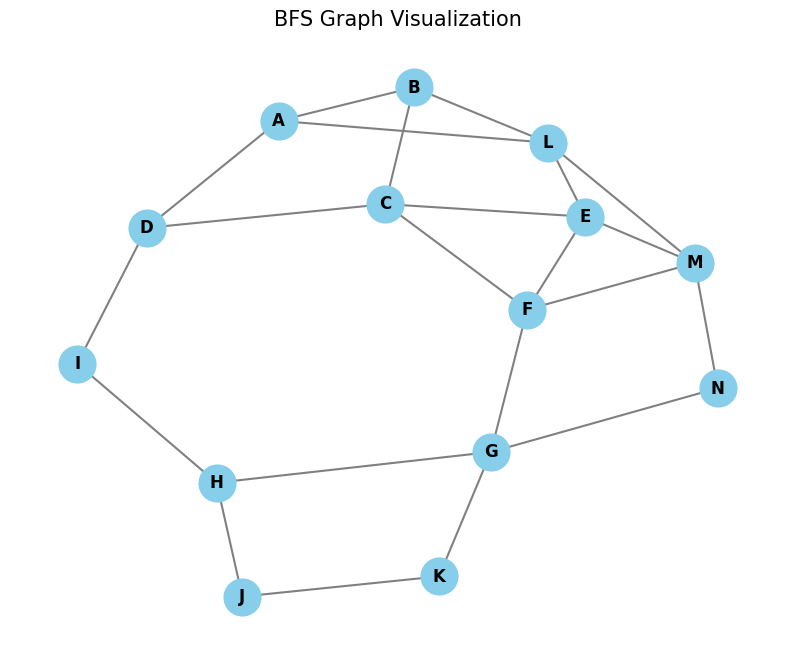

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph object from the BFSGraph dictionary
G_bfs = nx.Graph(BFSGraph)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_bfs, seed=42) # For reproducible layout
nx.draw_networkx_nodes(G_bfs, pos, node_size=700, node_color='skyblue')
nx.draw_networkx_edges(G_bfs, pos, width=1.5, edge_color='gray')
nx.draw_networkx_labels(G_bfs, pos, font_size=12, font_weight='bold')
plt.title('BFS Graph Visualization', size=15)
plt.axis('off') # Hide axes
plt.show()

## Dijkstra's Algorithm for Weighted Graph

In [6]:
import heapq

def dijkstra(graph, start, end):
    # distances: stores the shortest distance found so far to each node
    # priority_queue: stores tuples of (distance, node) to explore nodes with the smallest distance first
    # predecessors: stores the node that came before the current node in the shortest path
    distances = {node: float('infinity') for node in graph}
    distances[start] = 0
    priority_queue = [(0, start)]
    predecessors = {}

    print(f"Starting Dijkstra's from {start} to {end}")

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        # If we've already found a shorter path to this node, skip
        if current_distance > distances[current_node]:
            continue

        print(f"Selecting node: {current_node} with cost: {current_distance}")

        for neighbor, weight in graph[current_node]:
            distance = current_distance + weight

            # If a shorter path to the neighbor is found
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                predecessors[neighbor] = current_node
                heapq.heappush(priority_queue, (distance, neighbor))

    # Reconstruct the path
    path = []
    current = end
    while current in predecessors:
        path.insert(0, current)
        current = predecessors[current]
    if current == start: # Add the start node to the beginning of the path
        path.insert(0, start)

    if path[0] == start and path[-1] == end:
        return path, distances[end]
    else:
        return None, float('infinity') # Path not found

# Find and print the cheapest path using Dijkstra's
cheapest_path, total_cost = dijkstra(DijkstraGraph, 'A', 'K')

if cheapest_path and total_cost != float('infinity'):
    print(f"\nCheapest Path from A to K: {' -> '.join(cheapest_path)}")
    print(f"Total Cost: {total_cost}")
else:
    print("\nPath from A to K not found.")

Starting Dijkstra's from A to K
Selecting node: A with cost: 0
Selecting node: L with cost: 10
Selecting node: D with cost: 12
Selecting node: B with cost: 15
Selecting node: C with cost: 16
Selecting node: E with cost: 28
Selecting node: M with cost: 28
Selecting node: I with cost: 34
Selecting node: N with cost: 37
Selecting node: F with cost: 41
Selecting node: G with cost: 42
Selecting node: H with cost: 46
Selecting node: K with cost: 57
Selecting node: J with cost: 69

Cheapest Path from A to K: A -> L -> M -> N -> G -> K
Total Cost: 57


## Visualizing the Dijkstra (Weighted) Graph

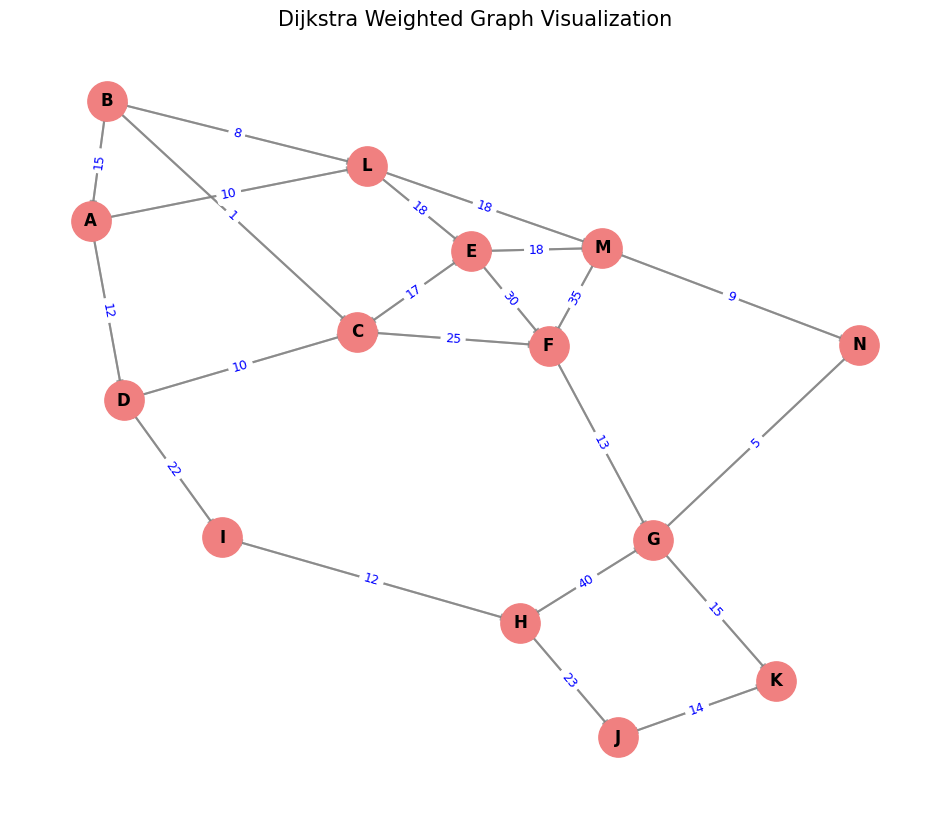

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph object from the DijkstraGraph dictionary
# Using DiGraph because weights are typically associated with directed edges for clarity, though Dijkstra works on undirected too
G_dijkstra = nx.DiGraph()

for node, neighbors in DijkstraGraph.items():
    for neighbor, weight in neighbors:
        G_dijkstra.add_edge(node, neighbor, weight=weight)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_dijkstra, seed=42) # For reproducible layout

nx.draw_networkx_nodes(G_dijkstra, pos, node_size=800, node_color='lightcoral')
nx.draw_networkx_edges(G_dijkstra, pos, width=1.5, alpha=0.7, edge_color='gray')
nx.draw_networkx_labels(G_dijkstra, pos, font_size=12, font_weight='bold', font_color='black')

# Add edge labels (weights)
edge_labels = nx.get_edge_attributes(G_dijkstra, 'weight')
nx.draw_networkx_edge_labels(G_dijkstra, pos, edge_labels=edge_labels, font_size=9, font_color='blue')

plt.title('Dijkstra Weighted Graph Visualization', size=15)
plt.axis('off') # Hide axes
plt.show()